In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import pandas as pd
from scipy.ndimage import gaussian_filter
import scipy.optimize as opt

In [134]:
fits_file = 'M41_pm_3.fits'
fits.info(fits_file)
fits.getheader(fits_file, ext=1)

Filename: M41_pm_3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1                1 BinTableHDU    157   2000R x 33C   [28A, K, D, D, D, D, D, E, E, E, E, E, E, 13A, I, L, L, L, L, L, L, L, E, E, E, E, E, E, E, 8A, D, D, D]   


XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional table                            
NAXIS1  =                  182 / width of table in bytes                        
NAXIS2  =                 2000 / number of rows in table                        
PCOUNT  =                    0 / heap size (no gap)                             
GCOUNT  =                    1 / one data group                                 
TFIELDS =                   33 / number of columns                              
TTYPE1  = 'designation'        / label for column 1                             
TFORM1  = '28A     '           / format for column 1                            
TCOMM1  = 'Unique source designation (unique across all Data Releases)'         
TUCD1   = 'meta.id;meta.main'  / VO Unified Content Descriptor for column 1     
TTYPE2  = 'source_id'       

In [135]:
with fits.open(fits_file) as hdul:
    data = hdul[1].data
tabla = Table(data)
print(tabla[:5])
df = tabla.to_pandas()
print(df.head())

        designation               source_id      ... target_separation (deg)
---------------------------- ------------------- ... -----------------------
Gaia DR3 2927008980895404928 2927008980895404928 ...    0.009720672614521595
Gaia DR3 2927008980895405056 2927008980895405056 ...    0.011217890065282055
Gaia DR3 2927008980895402368 2927008980895402368 ...    0.012853041521138696
Gaia DR3 2927008224981157760 2927008224981157760 ...     0.01581567692825537
Gaia DR3 2927008980887462400 2927008980887462400 ...    0.017236907327403378
                    designation            source_id          ra        dec  \
0  Gaia DR3 2927008980895404928  2927008980895404928  101.502278 -20.744786   
1  Gaia DR3 2927008980895405056  2927008980895405056  101.498937 -20.743019   
2  Gaia DR3 2927008980895402368  2927008980895402368  101.502818 -20.741685   
3  Gaia DR3 2927008224981157760  2927008224981157760  101.516279 -20.750904   
4  Gaia DR3 2927008980887462400  2927008980887462400  101.510297 -

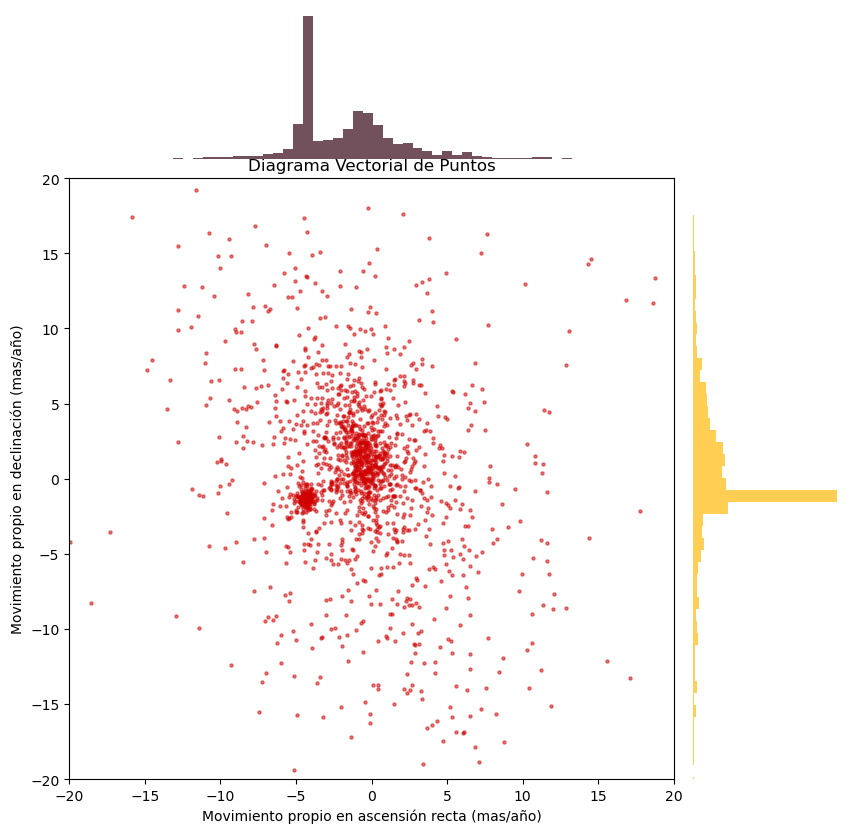

In [136]:
pmra = df['pmra']
pmdec = df['pmdec']

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=(4, 1),
    height_ratios=(1, 4),
    wspace=0.05,
    hspace=0.05
)

ax_hist_x = fig.add_subplot(gs[0, 0])
ax_scatter = fig.add_subplot(gs[1, 0], sharex=ax_hist_x)
ax_hist_y = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

ax_scatter.scatter(pmra, pmdec, s=5, alpha=0.5, color='#d00000')
ax_scatter.set_xlim(-20, 20)
ax_scatter.set_ylim(-20, 20)
ax_scatter.set_xlabel('Movimiento propio en ascensión recta (mas/año)')
ax_scatter.set_ylabel('Movimiento propio en declinación (mas/año)')
ax_scatter.set_title('Diagrama Vectorial de Puntos')

# Histograma superior (RA)
ax_hist_x.hist(pmra, bins=100, color='#370617', alpha=0.7, density=True)
ax_hist_x.tick_params(axis='x', labelbottom=False)
ax_hist_x.tick_params(axis='y', labelleft=False)
ax_hist_x.axis('off')  # Oculta los ejes del histograma superior

# Histograma derecho (Dec)
ax_hist_y.hist(pmdec, bins=100, color='#ffba08', alpha=0.7, orientation='horizontal', density=True)
ax_hist_y.tick_params(axis='y', labelleft=False)
ax_hist_y.tick_params(axis='x', labelbottom=False)
ax_hist_y.axis('off')  # Oculta los ejes del histograma derecho

plt.savefig('diagrama_vectorial.png', dpi=300, bbox_inches='tight')
plt.show()

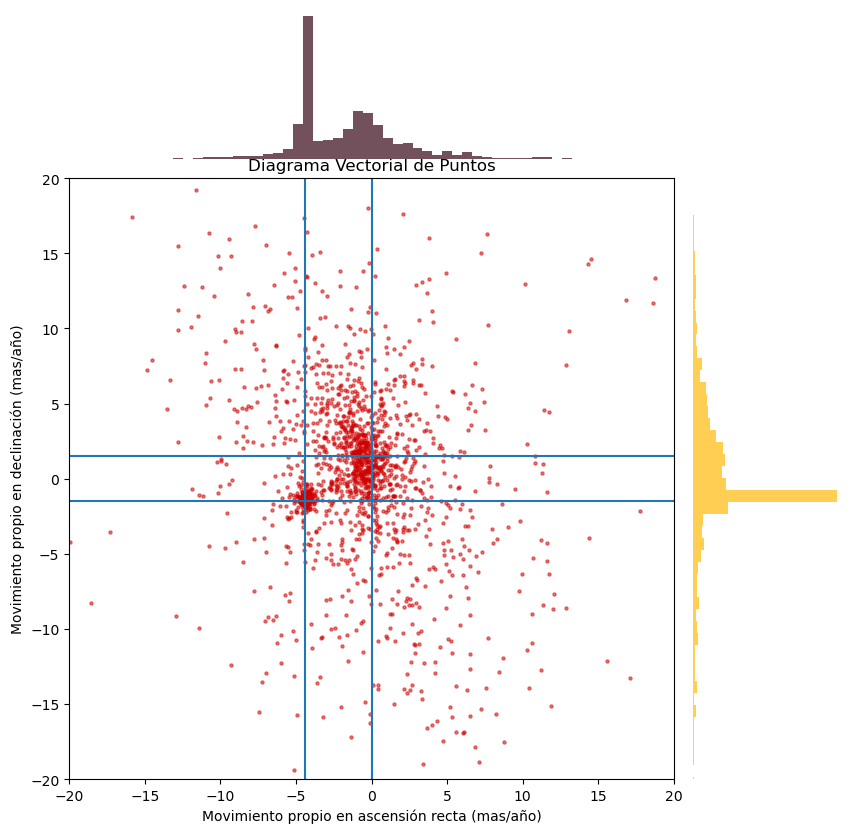

In [137]:
pmra = df['pmra']
pmdec = df['pmdec']

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=(4, 1),
    height_ratios=(1, 4),
    wspace=0.05,
    hspace=0.05
)

ax_hist_x = fig.add_subplot(gs[0, 0])
ax_scatter = fig.add_subplot(gs[1, 0], sharex=ax_hist_x)
ax_hist_y = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

ax_scatter.scatter(pmra, pmdec, s=5, alpha=0.5, color='#d00000')
ax_scatter.axvline(-4.4)
ax_scatter.axhline(-1.5)
ax_scatter.axvline(0)
ax_scatter.axhline(1.5)
ax_scatter.set_xlim(-20, 20)
ax_scatter.set_ylim(-20, 20)
ax_scatter.set_xlabel('Movimiento propio en ascensión recta (mas/año)')
ax_scatter.set_ylabel('Movimiento propio en declinación (mas/año)')
ax_scatter.set_title('Diagrama Vectorial de Puntos')

# Histograma superior (RA)
ax_hist_x.hist(pmra, bins=100, color='#370617', alpha=0.7, density=True)
ax_hist_x.tick_params(axis='x', labelbottom=False)
ax_hist_x.tick_params(axis='y', labelleft=False)
ax_hist_x.axis('off')  # Oculta los ejes del histograma superior

# Histograma derecho (Dec)
ax_hist_y.hist(pmdec, bins=100, color='#ffba08', alpha=0.7, orientation='horizontal', density=True)
ax_hist_y.tick_params(axis='y', labelleft=False)
ax_hist_y.tick_params(axis='x', labelbottom=False)
ax_hist_y.axis('off')  # Oculta los ejes del histograma derecho

plt.savefig('valores_iniciales.png', dpi=300, bbox_inches='tight')
plt.show()

In [138]:
#Algoritmo de optimización de parámetros: Método de máxima verosimilitud.
#Parámetros:
mu_ra_cum = -4.4
mu_dec_cum = -1.5
std_cum = 0.5
mu_ra_field = 0
mu_dec_field = 1.5
std_ra_field = 3
std_dec_field = 3
corr = 0
n_cum = 0.5
initial_params = [mu_ra_cum, mu_dec_cum, std_cum, mu_ra_field, mu_dec_field, std_ra_field, std_dec_field, corr, n_cum]

pmra_arr = np.asarray(df["pmra"], dtype=float)
pmdec_arr = np.asarray(df["pmdec"], dtype=float)

EPS = 1e-12

def dist_cum(mu_x, mu_y, mu_xo, mu_yo, std):
    return 1/(2*np.pi*std**2)*np.exp(-0.5*((mu_x-mu_xo)**2+(mu_y-mu_yo)**2)/std**2)

def dist_field(mu_x, mu_y, mu_xo, mu_yo, std_x, std_y, corr):
    denom = 2*np.pi*std_x*std_y*np.sqrt(1-corr**2)
    frst_exp = ((mu_x-mu_xo)**2)/std_x**2
    scnd_exp = ((mu_y-mu_yo)**2)/std_y**2
    cross_exp = (2*corr*(mu_x-mu_xo)*(mu_y-mu_yo))/(std_x*std_y)
    exp = np.exp(-0.5/(1-corr**2)*(frst_exp+scnd_exp-cross_exp))
    return exp/denom

def prob_cum(dist_cum, dist_field, nc):
    num = nc * dist_cum
    denom = (1 - nc) * dist_field + num
    return num / denom

def neg_log_likelihood(params):
    mu_ra_c, mu_dec_c, std_c, mu_ra_f, mu_dec_f, std_ra_f, std_dec_f, corr, nc = params
    if std_c <= 0 or std_ra_f <= 0 or std_dec_f <= 0 or nc <= 0 or nc >= 1 or corr < -1 or corr > 1:
        return EPS

    d_c = dist_cum(pmra_arr, pmdec_arr, mu_ra_c, mu_dec_c, std_c)
    d_f = dist_field(pmra_arr, pmdec_arr, mu_ra_f, mu_dec_f, std_ra_f, std_dec_f, corr)

    total = nc*d_c + (1-nc)*d_f
    return -np.sum(np.log(total+EPS))

bounds = [
    (None, None),   # mu_ra_c
    (None, None),   # mu_dec_c
    (0.01, None),  # std_c
    (None, None),   # mu_ra_f
    (None, None),   # mu_dec_f
    (0.1, None),  # std_ra_f
    (0.1, None),  # std_dec_f
    (-0.99, 0.99),  # corr
    (0.001, 0.999)    # nc
]

result = opt.minimize(
    neg_log_likelihood,
    initial_params,
    method="L-BFGS-B",
    bounds=bounds
)

print("Éxito:", result.success)
print("Mensaje:", result.message)
print("Parámetros óptimos:", result.x)


Éxito: True
Mensaje: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Parámetros óptimos: [-4.37294383 -1.36247444  0.1709988  -0.59979937  0.43689226  4.63461062
  6.46400592 -0.25338442  0.26449415]


In [139]:
# Cálculo de probabilidades de membresía usando parámetros optimizados
umbral = 0.5
mu_ra_c, mu_dec_c, std_c, mu_ra_f, mu_dec_f, std_ra_f, std_dec_f, corr, nc = result.x

d_c = dist_cum(pmra_arr, pmdec_arr, mu_ra_c, mu_dec_c, std_c)
d_f = dist_field(pmra_arr, pmdec_arr, mu_ra_f, mu_dec_f, std_ra_f, std_dec_f, corr)

probabilidades= prob_cum(dist_cum=d_c, dist_field=d_f, nc=nc)

miembros_cumulo = probabilidades > umbral

print("Número de estrellas del cúmulo:", np.sum(miembros_cumulo))
print("Número de estrellas en el campo:", np.sum(~miembros_cumulo))
print("Número total de estrellas:", len(probabilidades))

Número de estrellas del cúmulo: 532
Número de estrellas en el campo: 1468
Número total de estrellas: 2000


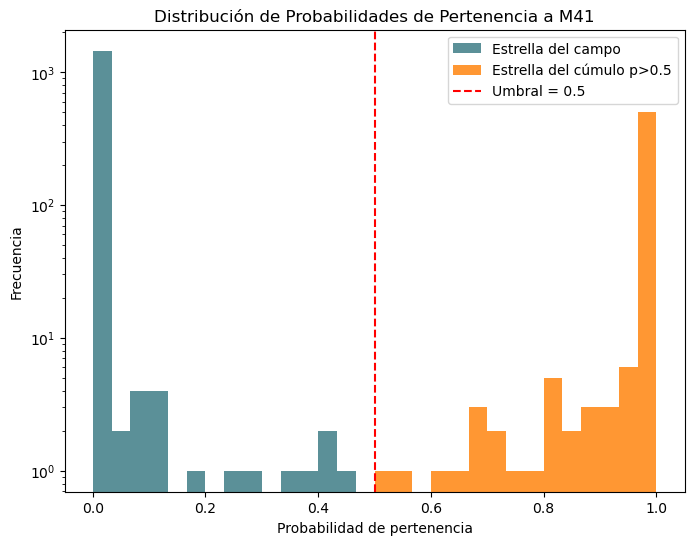

In [144]:
# Grafico de probabilidades (coloreando por umbral)
plt.figure(figsize=(8, 6))

bins = np.linspace(0, 1, 31)
mask_bajo = probabilidades <= umbral
mask_alto = probabilidades > umbral

plt.hist(probabilidades[mask_bajo], bins=bins, color='#15616d', alpha=0.7, label='Estrella del campo')
plt.hist(probabilidades[mask_alto], bins=bins, color='#ff7d00', alpha=0.8, label='Estrella del cúmulo p>0.5')
plt.axvline(umbral, color='red', linestyle='--', label=f'Umbral = {umbral}')

plt.xlabel('Probabilidad de pertenencia')
plt.ylabel('Frecuencia')
plt.yscale('log')
plt.title('Distribución de Probabilidades de Pertenencia a M41')
plt.legend()
plt.savefig('probabilidades_pertenencia.png', dpi=300, bbox_inches='tight')
plt.show()

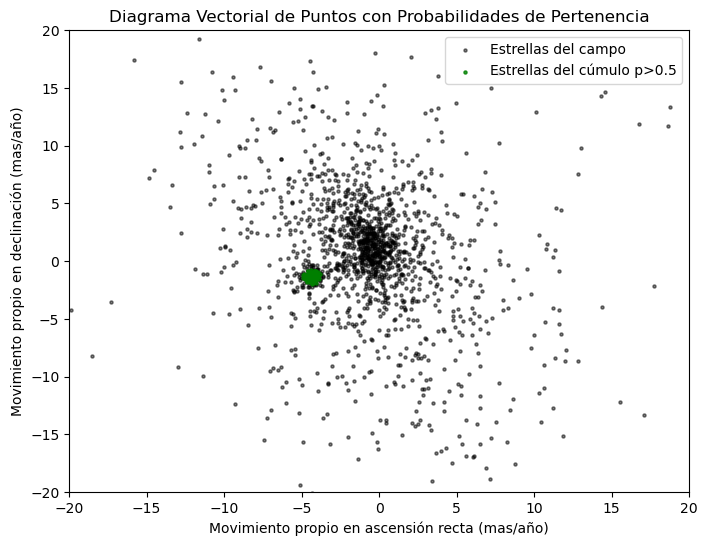

In [145]:
# Gráfico de diagrama vectorial coloreado por probabilidad
pmra_miembros = pmra[miembros_cumulo]
pmdec_miembros = pmdec[miembros_cumulo]
plt.figure(figsize=(8, 6))
plt.scatter(pmra, pmdec, s=5, alpha=0.5, color='black', label='Estrellas del campo')
plt.scatter(pmra_miembros, pmdec_miembros, s=5, alpha=0.8, color='green', label='Estrellas del cúmulo p>0.5')
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.title('Diagrama Vectorial de Puntos con Probabilidades de Pertenencia')
plt.xlabel('Movimiento propio en ascensión recta (mas/año)')
plt.ylabel('Movimiento propio en declinación (mas/año)')
plt.legend()
plt.savefig('diagrama_vectorial_probabilidades.png', dpi=300, bbox_inches='tight')


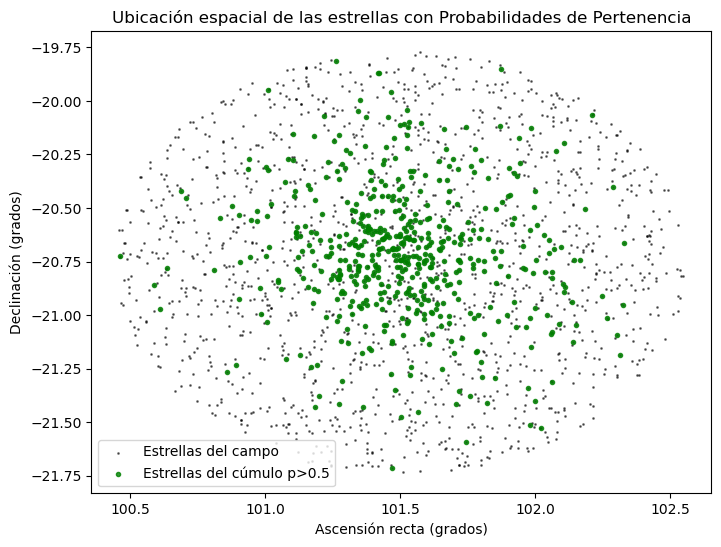

In [146]:
#Grafico de ubicacion espacial
ra = df['ra']
dec = df['dec']
ra_miembros = ra[miembros_cumulo]
dec_miembros = dec[miembros_cumulo]
plt.figure(figsize=(8, 6))
plt.scatter(ra, dec, s=1, alpha=0.5, color='black', label='Estrellas del campo')
plt.scatter(ra_miembros, dec_miembros, s=9, alpha=0.8, color='green', label='Estrellas del cúmulo p>0.5')
plt.title('Ubicación espacial de las estrellas con Probabilidades de Pertenencia')
plt.xlabel('Ascensión recta (grados)')
plt.ylabel('Declinación (grados)')
plt.legend()
plt.savefig('ubicacion_espacial_probabilidades.png', dpi=300, bbox_inches='tight')

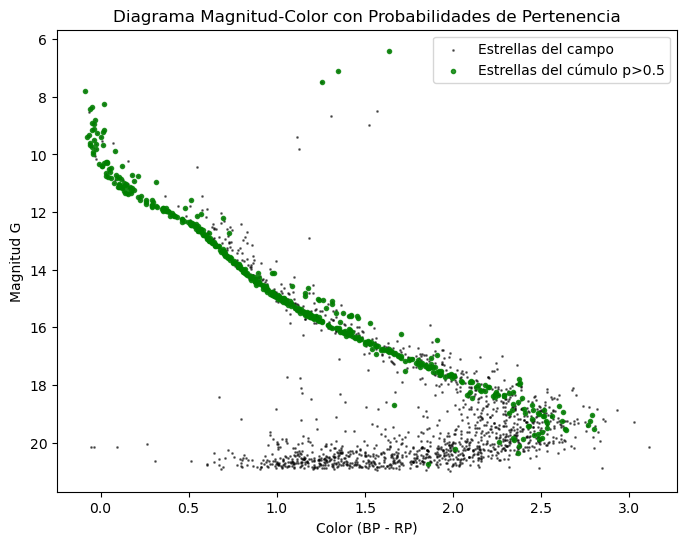

In [147]:
#Diagrama magnitud-color
g_mag = df['phot_g_mean_mag']
bp_mag = df['phot_bp_mean_mag']
rp_mag = df['phot_rp_mean_mag']
color = bp_mag - rp_mag
g_mag_miembros = g_mag[miembros_cumulo]
color_miembros = color[miembros_cumulo]
plt.figure(figsize=(8, 6))
plt.scatter(color, g_mag, s=1, alpha=0.5, color='black', label='Estrellas del campo')
plt.scatter(color_miembros, g_mag_miembros, s=9, alpha=0.8, color='green', label='Estrellas del cúmulo p>0.5')
plt.title('Diagrama Magnitud-Color con Probabilidades de Pertenencia')
plt.xlabel('Color (BP - RP)')
plt.ylabel('Magnitud G')
plt.gca().invert_yaxis()
plt.legend()
plt.savefig('diagrama_magnitud_color_probabilidades.png', dpi=300, bbox_inches='tight')